In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
import torch
import torch.optim as optim
from torchvision import datasets, transforms, models  # datsets  , transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime
from torch.utils.data import DataLoader

In [47]:
%pip install scikit-learn seaborn

  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl (8.9 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ---------------------------------------- 0.0/38.7 MB ? eta -:--:--
    --------------------------------------- 0.8/38.7 MB 4.2 MB/s eta 0:00:10
   - -------------------------------------- 1.8/38.7 MB 4.8 MB/s eta 0:00:08
   -- ------------------------------------- 2.9/38.7 MB 5.1 MB/s eta 0:00:08
   ---- ----------------------------------- 3.9/38.7 MB 4.9 MB/s eta 0:00:08
   ---- ----------------------------------- 4.7/38.7 MB 4.9 MB/s eta 0:00:07
   ------ --------------------------------- 6.0/38.7 MB 5.1 MB/s eta 0:00:07
   ------- ----------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

## Import Dataset

##### 1. applying transformation that are necessary to train the model

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet means
                         std=[0.229, 0.224, 0.225])
])

##### 2. Importing the dataset

In [4]:
dataset = datasets.ImageFolder("augmented_dataset", transform=transform)

In [5]:
dataset

Dataset ImageFolder
    Number of datapoints: 32357
    Root location: augmented_dataset
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [6]:
indices = list(range(len(dataset)))

In [7]:
split = int(np.floor(0.85 * len(dataset)))

In [8]:
validation = int(np.floor(0.70 * split))

In [9]:
print(0, validation, split, len(dataset))

0 19252 27503 32357


In [10]:
print(f"length of train size :{validation}")
print(f"length of validation size :{split - validation}")
print(f"length of test size :{len(dataset)-validation}")

length of train size :19252
length of validation size :8251
length of test size :13105


In [11]:
np.random.shuffle(indices)

## Split into Train and Test

In [12]:
train_indices, validation_indices, test_indices = (
    indices[:validation],
    indices[validation:split],
    indices[split:],
)

In [13]:
train_sampler = SubsetRandomSampler(train_indices)
validation_sampler = SubsetRandomSampler(validation_indices)
test_sampler = SubsetRandomSampler(test_indices)

## Convolution Model

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
batch_size = 32

In [16]:
train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=batch_size, sampler=validation_sampler)
test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

## Loading Resent Model

In [36]:
model = models.resnet18(pretrained=True)

d:\Plant_leaf_diseases_dataset\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Plant_leaf_diseases_dataset\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Sujal20/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:24<00:00, 1.90MB/s]


In [37]:
num_classes = len(dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [38]:
model = model.to(device)

In [39]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

## Training the cnn model

In [41]:
num_epochs = 10

In [42]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

# --- Initialize lists to store metrics ---
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # ---- TRAIN ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    train_loss /= len(train_loader)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total
    val_loss /= len(val_loader)

    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # ---- Store metrics for plotting ----
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


Epoch [1/10]


Training: 100%|██████████| 602/602 [03:28<00:00,  2.89it/s]


Train Loss: 0.7200, Train Acc: 79.29%


Validation: 100%|██████████| 258/258 [00:58<00:00,  4.42it/s]


Val Loss: 0.4415, Val Acc: 87.01%

Epoch [2/10]


...

Val Loss: 0.2595, Val Acc: 91.12%

Epoch [10/10]


Training: 100%|██████████| 602/602 [02:20<00:00,  4.29it/s]


Train Loss: 0.2606, Train Acc: 91.13%


Validation: 100%|██████████| 258/258 [00:54<00:00,  4.73it/s]

Val Loss: 0.2547, Val Acc: 91.53%


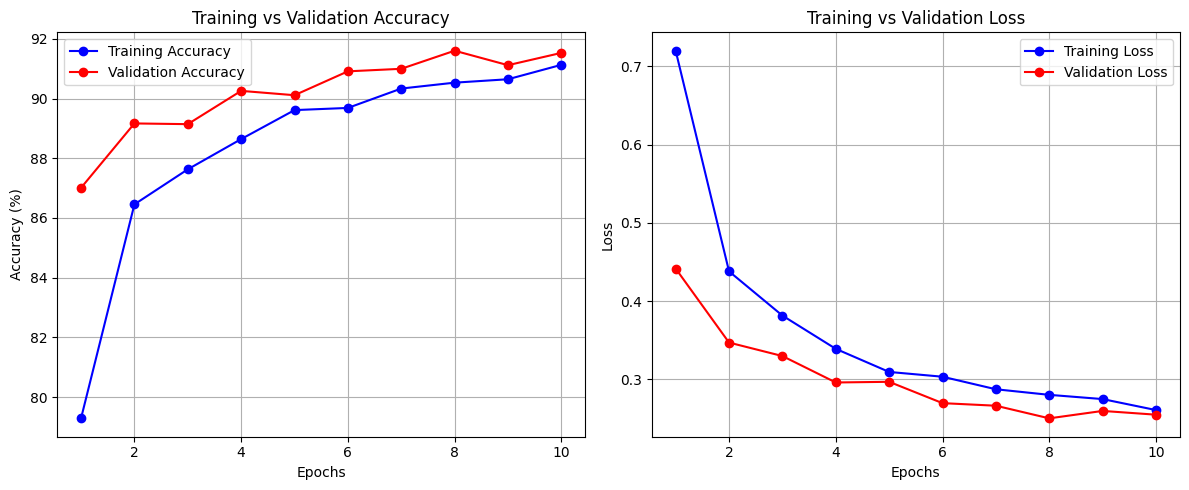

In [43]:
# ======================================================
# 📊 PLOT TRAINING vs VALIDATION ACCURACY AND LOSS
# ======================================================
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'r-o', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [44]:
# --- SAVE MODEL ---
torch.save(model.state_dict(), "resnet18_trained.pth")
print("✅ Model saved as 'resnet18_trained.pth'")

✅ Model saved as 'resnet18_trained.pth'


Testing: 100%|██████████| 152/152 [00:18<00:00,  8.17it/s]



===== Test Metrics =====
Accuracy: 90.21%
Precision: 0.9041
Recall: 0.9021
F1 Score: 0.9019

Classification Report:
                                                precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.87      0.95      0.91       433
                        Tomato___Early_blight       0.82      0.80      0.81       439
                         Tomato___Late_blight       0.91      0.81      0.86       467
                           Tomato___Leaf_Mold       0.85      0.92      0.88       435
                  Tomato___Septoria_leaf_spot       0.87      0.88      0.88       448
Tomato___Spider_mites Two-spotted_spider_mite       0.94      0.81      0.87       454
                         Tomato___Target_Spot       0.81      0.88      0.84       465
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.96      0.97       834
                 Tomato___Tomato_mosaic_virus       0.95      0.98      0.97       460
           

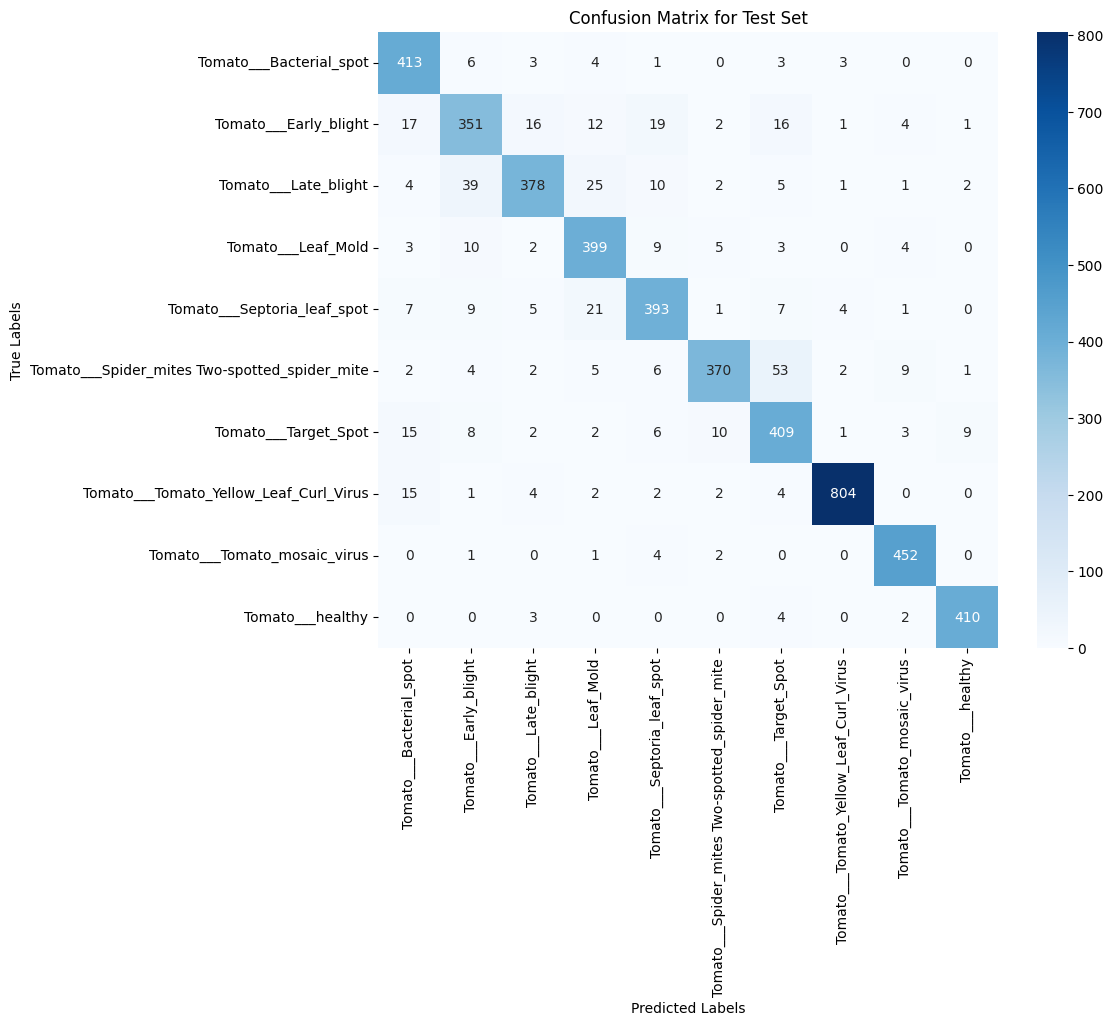

In [49]:
model.eval()
all_labels, all_preds = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Calculate metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("\n===== Test Metrics =====")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=dataset.classes))

# ===============================
# 6️⃣ Confusion Matrix Visualization
# ===============================
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.title("Confusion Matrix for Test Set")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()